In [ ]:
import sqlite3
#python's buildin db library
#allows pythin to create,connect to,query sqlite db
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')



In [ ]:
df=pd.read_csv('student_performance.csv')
print("no of Rows:",df.shape[0])
print("no of columns:",df.shape[1])

no of Rows: 30
no of columns: 13


sqlite3.connect()--creates or opens db file

conn--is the connection object--our link to the db

cursor--tool that executes SQL commands

df.to_sql()--write dataframe as database table

In [ ]:
#sqlite3.connect()-creates or opens a database file
#conn- connection object-our link to the database
#cursor- tool that executes that sql commands
#df.to_sql-writes the dataframes as a database tables

#STEP-1 Connect to a database file
conn=sqlite3.connect('college.db')
#STEP-2 Create a Cusor- SQL Execution tool
cursor=conn.cursor()
#STEP-3 Write the dataframe to a database table
df.to_sql(
    name='students',
    con=conn,
    index=False,    #index starts with 1
    if_exists='replace'
)
#STEP-4 Verify table was created or not
cursor.execute("SELECT COUNT(*) FROM students")

count=cursor.fetchone()[0]
#fetchone() retrives the first result row
#[0] gets the first value from that row

print(f"Database 'college.db' created successfully!")
print(f"Number of rows in the 'students' table: {count}")

Database 'college.db' created successfully!
Number of rows in the 'students' table: 30


In [ ]:
cursor.execute("SELECT * from students")
result=cursor.fetchall()
print(result)
print("-"*1000)
cursor.execute("SELECT * from students")
result2=cursor.fetchone()
print(result2)

[(1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023), (1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023), (1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023), (1004, 'Sneha Reddy', 20, 'Female', 'Mechanical', 2, 70, 80, 75, 48, 95, 'Hyderabad', 2023), (1005, 'Arjun Nair', 19, 'Male', 'Computer Science', 2, 92, 88, 81, 95, 90, 'Kochi', 2023), (1006, 'Meera Joshi', 20, 'Female', 'Electronics', 2, 58, 66, 70, 52, 72, 'Pune', 2023), (1007, 'Kiran Kumar', 21, 'Male', 'Civil', 2, 73, 69, 65, 40, 85, 'Bangalore', 2023), (1008, 'Divya Singh', 19, 'Female', 'Computer Science', 2, 88, 91, 84, 93, 96, 'Lucknow', 2023), (1009, 'Rahul Mishra', 20, 'Male', 'Mechanical', 2, 62, 71, 58, 45, 68, 'Varanasi', 2023), (1010, 'Ananya Das', 19, 'Female', 'Computer Science', 2, 95, 89, 90, 97, 98, 'Kolkata', 2023), (1011, 'Vikram Iyer', 20, 'Male', 'Electronics', 2, 80, 75, 68, 72, 83, '

In [ ]:
cursor.execute("PRAGMA table_info(students)")

columns_info = cursor.fetchall()

print("Table Structure of 'students':")
print(f"{'Column Name':<25}{'Data Types':<12}")
print("-" * 30)

for column in columns_info:
    print(f"{column[1]:<25}{column[2]:<12}")

Table Structure of 'students':
Column Name              Data Types  
------------------------------
student_id               INTEGER     
name                     TEXT        
age                      INTEGER     
gender                   TEXT        
department               TEXT        
semester                 INTEGER     
math_score               INTEGER     
science_score            INTEGER     
english_score            INTEGER     
programming_score        INTEGER     
attendance_percentage    INTEGER     
city                     TEXT        
admission_year           INTEGER     


In [ ]:
def run_query(sql,description=""):
  if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"{'-'*55}")
  result=pd.read_sql_query(sql,conn)
  return result

In [ ]:
query1="""
select student_id,name,department,math_score,attendance_percentage
from students
limit 10
"""
result1=run_query(query1,"Query 1: First 10 Students(SELECT + LIMIT)")
print(result1)


Query 1: First 10 Students(SELECT + LIMIT)
-------------------------------------------------------
   student_id          name        department  math_score  \
0        1001  Aarav Sharma  Computer Science          85   
1        1002   Priya Patel  Computer Science          76   
2        1003   Rohit Verma       Electronics          65   
3        1004   Sneha Reddy        Mechanical          70   
4        1005    Arjun Nair  Computer Science          92   
5        1006   Meera Joshi       Electronics          58   
6        1007   Kiran Kumar             Civil          73   
7        1008   Divya Singh  Computer Science          88   
8        1009  Rahul Mishra        Mechanical          62   
9        1010    Ananya Das  Computer Science          95   

   attendance_percentage  
0                     92  
1                     87  
2                     78  
3                     95  
4                     90  
5                     72  
6                     85  
7           

In [ ]:
query1 = """
SELECT student_id, name, department, math_score, attendance_percentage
FROM students
ORDER BY student_id DESC
LIMIT 5
"""

result1 = run_query(query1, "Query 1: Last 5 Students")

print(result1)


Query 1: Last 5 Students
-------------------------------------------------------
   student_id            name        department  math_score  \
0        1030  Akanksha Yadav  Computer Science          91   
1        1029      Nitin Jain        Mechanical          75   
2        1028   Sunita Pillai             Civil          60   
3        1027   Gaurav Shukla  Computer Science          84   
4        1026      Rekha Nair       Electronics          72   

   attendance_percentage  
0                     95  
1                     84  
2                     73  
3                     87  
4                     82  


In [ ]:
query1 = """
SELECT student_id, name, science_score, math_score, english_score, programming_score
FROM students
WHERE student_id BETWEEN 1026 AND 1030
ORDER BY student_id ASC
"""
result1 = run_query(query1, "Query 1: Last 5 Students")

print(result1)


Query 1: Last 5 Students
-------------------------------------------------------
   student_id            name  science_score  math_score  english_score  \
0        1026      Rekha Nair             77          72             73   
1        1027   Gaurav Shukla             79          84             75   
2        1028   Sunita Pillai             65          60             68   
3        1029      Nitin Jain             76          75             70   
4        1030  Akanksha Yadav             93          91             87   

   programming_score  
0                 63  
1                 87  
2                 39  
3                 50  
4                 94  


In [ ]:
query1 = """
SELECT student_id, name,programming_score
FROM students
WHERE programming_score BETWEEN 50 AND 70
ORDER BY programming_score ASC
"""

result1 = run_query(query1, "Students with Programming Score between 50–70")

print(result1)


Students with Programming Score between 50–70
-------------------------------------------------------
   student_id           name  programming_score
0        1029     Nitin Jain                 50
1        1014  Kavya Nambiar                 51
2        1006    Meera Joshi                 52
3        1024  Preeti Saxena                 53
4        1003    Rohit Verma                 55
5        1021  Harish Pillai                 58
6        1026     Rekha Nair                 63
7        1016   Ritu Agarwal                 69


In [ ]:
query3= """
SELECT name,math_score,science_score,programming_score
FROM students
WHERE department IN ('Computer Science','Electronic','Mechanical')
ORDER BY programming_score DESC
LIMIT 1
"""
result3=run_query(query3,"Query 3: top Student")
print(result3)


Query 3: top Student
-------------------------------------------------------
         name  math_score  science_score  programming_score
0  Ananya Das          95             89                 97


In [ ]:
query4 = """
SELECT name, department, attendance_percentage
FROM students
WHERE attendance_percentage > 80
AND attendance_percentage != 90
ORDER BY attendance_percentage DESCattendance_percentage$0
"""

result4 = run_query(query4, "Students Attendance")

print(result4)


Students Attendance
-------------------------------------------------------
              name        department  attendance_percentage
0       Ananya Das  Computer Science                     98
1      Tanvi Mehta  Computer Science                     97
2      Divya Singh  Computer Science                     96
3      Sneha Reddy        Mechanical                     95
4   Akanksha Yadav  Computer Science                     95
5   Swati Kulkarni  Computer Science                     94
6     Ritu Agarwal       Electronics                     93
7     Aarav Sharma  Computer Science                     92
8    Kavya Nambiar        Mechanical                     91
9        Amit Bose  Computer Science                     91
10    Nisha Kapoor  Computer Science                     89
11      Suresh Rao  Computer Science                     88
12     Priya Patel  Computer Science                     87
13   Gaurav Shukla  Computer Science                     87
14   Preeti Saxena     

In [ ]:
dept_data = {
    'dept_code':['CS','EC','ME','CE'],
    'dept_name':['Computer Science','Electronics','Mechanical','Civil'],
    'Hod_name':['Dr. A','Dr. B','Dr. C','Dr. D'],
    'established':[1985,1988,1972,1965],
    'intake':[60,60,60,60]
}

dept_df = pd.DataFrame(dept_data)

dept_df.to_sql('departments', conn, if_exists='replace', index=False)

print("Created 'departments' table")
print(dept_df.to_string(index=False))

dept_map = {
    'Computer Science':'CS',
    'Electronics':'EC',
    'Mechanical':'ME',
    'Civil':'CE'
}

Created 'departments' table
dept_code        dept_name Hod_name  established  intake
       CS Computer Science    Dr. A         1985      60
       EC      Electronics    Dr. B         1988      60
       ME       Mechanical    Dr. C         1972      60
       CE            Civil    Dr. D         1965      60


In [ ]:
query_join = """
SELECT
s.name,
s.math_score,
d.hod_name,
d.established
FROM students AS s
INNER JOIN departments AS d
ON s.department = d.dept_name
ORDER BY s.math_score DESC
LIMIT 8
"""

result = run_query(query_join, "Top 8 Students with Department Details")

print(result)


Top 8 Students with Department Details
-------------------------------------------------------
             name  math_score Hod_name  established
0      Ananya Das          95    Dr. A         1985
1     Tanvi Mehta          93    Dr. A         1985
2      Arjun Nair          92    Dr. A         1985
3  Akanksha Yadav          91    Dr. A         1985
4  Swati Kulkarni          90    Dr. A         1985
5     Divya Singh          88    Dr. A         1985
6    Ritu Agarwal          87    Dr. B         1988
7       Amit Bose          86    Dr. A         1985


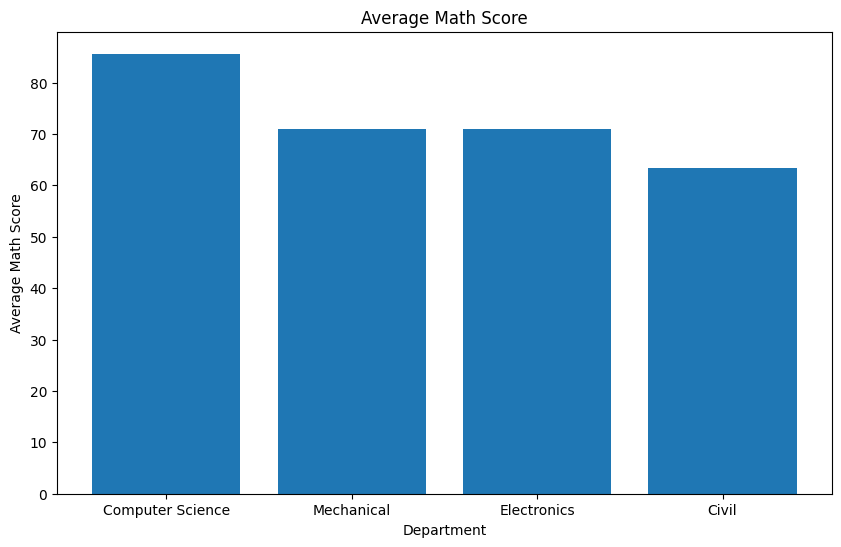

In [ ]:
chart1_sql = """
SELECT department,
ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
chart1_data = pd.read_sql_query(chart1_sql, conn)
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(
    chart1_data['department'],
    chart1_data['avg_math']
)

ax.set_title("Average Math Score")
ax.set_xlabel("Department")
ax.set_ylabel("Average Math Score")

plt.show()